<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Advanced Machine Learning</p>

<p style="text-align: center;"> Course code: 203238427 </p>

<p style="text-align: center;"> Group: 01 </p>

<p style="text-align: center;"> Phase 3 - Ensemble learning</p>

<p style="text-align: center;">  Presented by: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: Rafael Gaitán Ospina </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, March 2026</p>

# Load dataset

In [1]:
from sklearn.datasets import fetch_openml

df_reg = fetch_openml(data_id=560, parser='auto')
df_class = fetch_openml(data_id=37, parser='auto')


In this phase we will use some data from [Open ML](https://www.openml.org/) which is an open platform that allows to share datasets, algorithms and experimets to learn. In this case, we will use two data sets, one related to estimates of the percentage of body fat determined by underwater weighing Bodyfat ([ID: 560](openml.org/search?type=data&status=active&id=560)); and the other to cases of diabetes on a group of females of Pima Indian heritage ([ID: 37](openml.org/search?type=data&status=active&id=560))

In [3]:
# In all exercises we will need to calculate the metrics of each model and the learning curves
# with this in mind, we will be creating some functions to easy calculate them

# First we will import the main libraries we will need for each function.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
    )

from sklearn.model_selection import learning_curve


def classification_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate and display classification metrics.
    
    Parameters:
    -----------
    y_true : array-like  — True labels
    y_pred : array-like  — Predicted labels
    model_name : str     — Label to display
    
    Returns:
    --------
    dict with metric names and values
    """
    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_score':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    
    print(f"\n{'='*50}")
    print(f"  Classification Metrics — {model_name}")
    print(f"{'='*50}")
    
    for name, value in metrics.items():
        print(f"  {name.capitalize():<12}: {value:.4f}")
    print(f"{'='*50}")
    
    return metrics


def regression_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate and display regression metrics.
    
    Parameters:
    -----------
    y_true : array-like  — True values
    y_pred : array-like  — Predicted values
    model_name : str     — Label to display
    
    Returns:
    --------
    dict with metric names and values
    """
    metrics = {
        'mse': mean_squared_error(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2':  r2_score(y_true, y_pred),
    }
    
    print(f"\n{'='*50}")
    print(f"  Regression Metrics — {model_name}")
    print(f"{'='*50}")
    
    print(f"  MSE          : {metrics['mse']:.4f}")
    print(f"  MAE          : {metrics['mae']:.4f}")
    print(f"  R² Score     : {metrics['r2']:.4f}")
    print(f"{'='*50}")
    
    return metrics

def plot_learning_curve(estimator, X, y, title, cv, scoring, ax=None):
    """
    Plot the learning curve for a given estimator.

    Parameters:
    -----------
    estimator   : sklearn estimator
    X           : feature matrix
    y           : target vector
    title       : str — plot title
    cv          : cross-validation strategy
    scoring     : str — sklearn scoring metric
    ax          : matplotlib Axes (optional)
    """
    train_sizes = np.linspace(0.1, 1.0, 8)
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(train_sizes_abs, train_mean, 'o-', color='royalblue',  label='Training score')
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
    ax.plot(train_sizes_abs, val_mean,   's-', color='tomato', label='Validation score')
    ax.fill_between(train_sizes_abs, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color='tomato')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel(scoring)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    return ax

# Exercise 1: Voting and Stacking.

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler

# Base classifiers (for Voting)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Base regressors (for Stacking)
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Ensemble methods
from sklearn.ensemble import VotingClassifier, StackingRegressor

---
## Voting

The idea behind the Voting Classifier is to combine conceptually different machine learning classifiers and use a majority vote (hard vote) or the average predicted probabilities (soft vote) to predict the class labels. Such classifier can be useful for a set of equally well performing models in order to balance out their individual weaknesses. To resume we have:

* **Hard Voting**: The final prediction is the **majority vote** of base classifiers.
Each classifier votes for a class and the class with the most votes wins.

* **Soft Voting**: Each classifier outputs **class probabilities**; these are averaged across classifiers and the class with the highest average probability wins.
Soft voting tends to outperform hard voting when classifiers are well-calibrated.

In [14]:
X_class = df_class['data']
y_class = df_class['target']

y_class = y_class.map({'tested_positive': 1, 'tested_negative': 0})

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.25, random_state=42)

scaler_class = StandardScaler().set_output(transform="pandas")
X_train_stand = scaler_class.fit_transform(X_train_class)
X_test_stand  = scaler_class.transform(X_test_class)

print(f"Train size: {X_train_stand.shape}, Test size: {X_test_stand.shape}")


Train size: (576, 8), Test size: (192, 8)


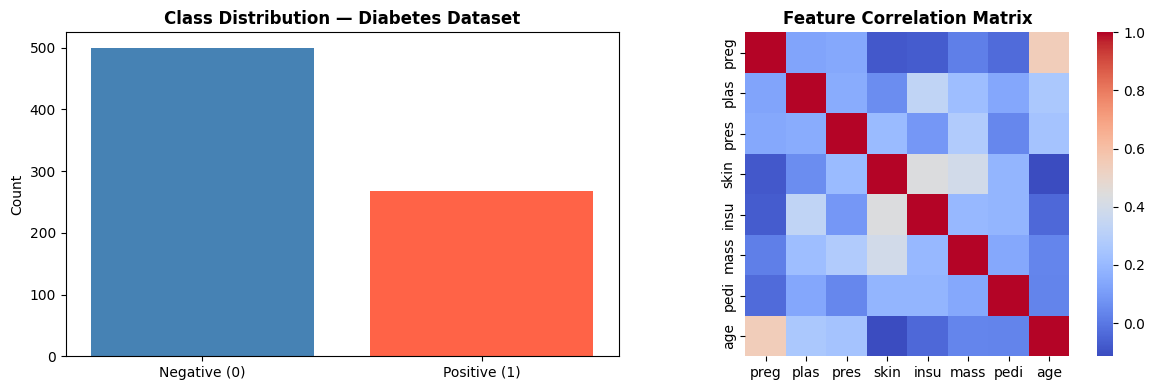

In [18]:
# Quick visual overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Negative (0)', 'Positive (1)'], np.bincount(y_class), color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution — Diabetes Dataset', fontweight='bold')
axes[0].set_ylabel('Count')

# Feature correlation heatmap
corr = X_class.corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', fmt='.1f', annot=False, square=True)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
class_estimators = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("K-Neighbors", KNeighborsClassifier(n_neighbors=7))
]

# Train and evaluate each base classifier individually
print("--- Base Classifier Accuracy on Test Set ---")

for name, model in class_estimators:
    model.fit(X_train_class, y_train_class)
    y_pred = model.predict(X_test_stand)
    
    metrics_hard = classification_metrics(y_test_class, y_pred, name)


print("--- Base Classifier Accuracy on Test Set ---")
# Hard voting: majority class vote
hard_voter = VotingClassifier(estimators=class_estimators, voting='hard')
hard_voter.fit(X_train_class, y_train_class)
y_pred_hard = hard_voter.predict(X_test_class)

metrics_hard = classification_metrics(y_test_class, y_pred_hard, "Hard Voting")

# Hard voting: majority class vote
soft_voter = VotingClassifier(estimators=class_estimators, voting='soft')
soft_voter.fit(X_train_class, y_train_class)
y_pred_soft = soft_voter.predict(X_test_class)

metrics_soft = classification_metrics(y_test_class, y_pred_soft, "Soft Voting")

--- Base Classifier Accuracy on Test Set ---

  Classification Metrics — Logistic Regression
  Accuracy    : 0.6406
  Precision   : 0.4104
  Recall      : 0.6406
  F1_score    : 0.5003

  Classification Metrics — Decision Tree
  Accuracy    : 0.6406
  Precision   : 0.4104
  Recall      : 0.6406
  F1_score    : 0.5003

  Classification Metrics — K-Neighbors
  Accuracy    : 0.6406
  Precision   : 0.4104
  Recall      : 0.6406
  F1_score    : 0.5003

  Classification Metrics — Hard Voting
  Accuracy    : 0.7240
  Precision   : 0.7249
  Recall      : 0.7240
  F1_score    : 0.7244

  Classification Metrics — Soft Voting
  Accuracy    : 0.7083
  Precision   : 0.7103
  Recall      : 0.7083
  F1_score    : 0.7092


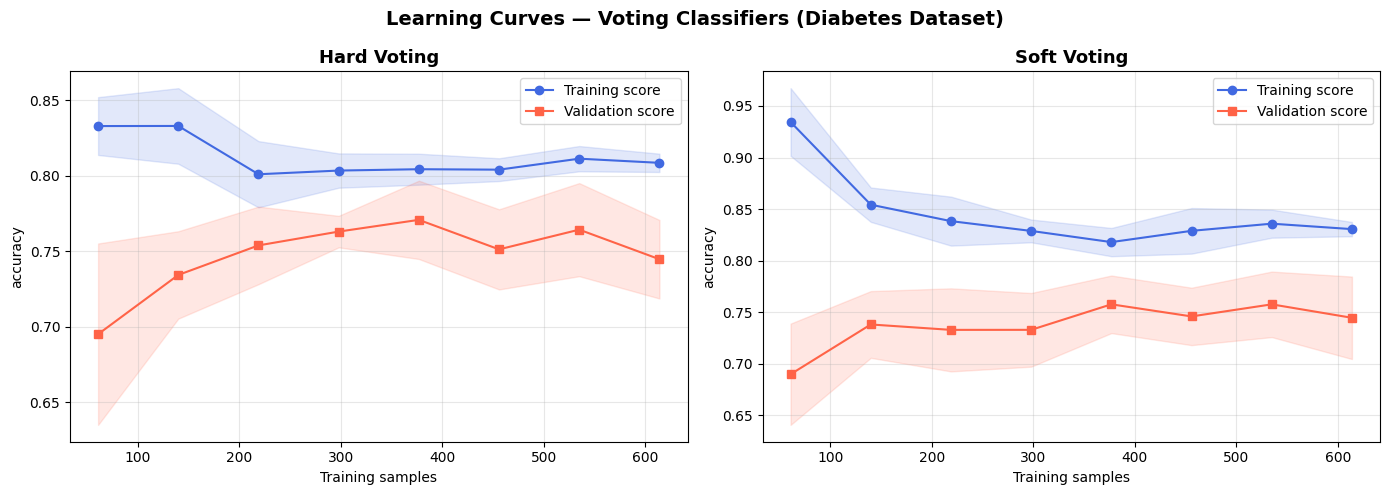

In [17]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Voting Classifiers (Diabetes Dataset)', fontsize=14, fontweight='bold')

plot_learning_curve(
    VotingClassifier(estimators=class_estimators, voting='hard'),
    X_class, y_class,
    title='Hard Voting',
    cv=cv_strat,
    scoring='accuracy',
    ax=axes[0]
)

plot_learning_curve(
    VotingClassifier(estimators=class_estimators, voting='soft'),
    X_class, y_class,
    title='Soft Voting',
    cv=cv_strat,
    scoring='accuracy',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

## Stacking

In [ ]:
X = df_reg['data']
y = df_reg['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Metrics

## Learning curves

## Conclusions

# Exercise 2: Bagging.

## Metrics

## Learning curves

## Conclusions

# Exercise 3: Boosting.

## Metrics

## Learning curves

## Conclusions

# Exercise 4: Random Forest.

## Metrics

## Learning curves

## Conclusions

# References

In [ ]:
import bibtexparser

with open("../references.bib", "r", encoding="utf-8") as bib_file:
    bib_database = bibtexparser.load(bib_file)

for i, entry in enumerate(bib_database.entries, 1):
    url = entry.get("url", "unknown")
    authors    = entry.get("author", "Unknown Author")
    title      = entry.get("title", "No Title")
    year       = entry.get("year", "n.d.")
    journal    = entry.get("journal", entry.get("booktitle", ""))
    
    print(f"[{i}] {authors} ({year}). \033[3m{title}\033[0m. {journal} [{url}]")
    print()